# TP3 — Regresión: California Housing Dataset

**Objetivo:** Predecir el precio medio de viviendas en California usando regresión lineal y polinómica.

Dataset fuente: [scikit-learn — California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)

---
## 1. Imports y carga del dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

---
## 2. Exploración del dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("=== Descripción del dataset ===")
print(housing.DESCR[:1200])

=== Descripción del dataset ===
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U

In [3]:
print(f"Shape: {df.shape}")
print(f"Features: {housing.feature_names}")
print(f"Target: MedHouseVal (precio mediano en cientos de miles de dólares)")
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (precio mediano en cientos de miles de dólares)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


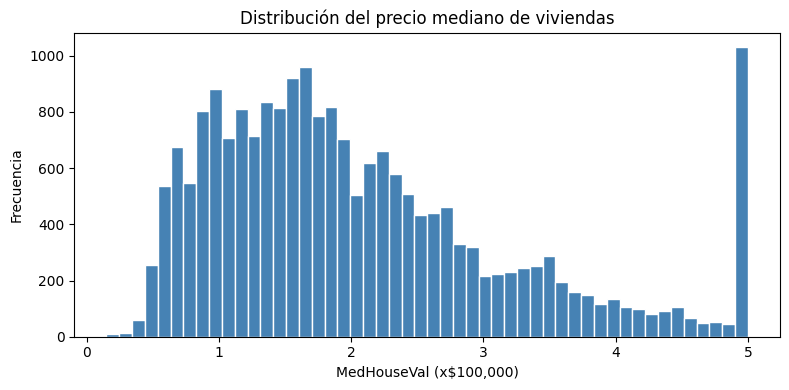

In [6]:
# Distribución del target
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución del precio mediano de viviendas')
plt.xlabel('MedHouseVal (x$100,000)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

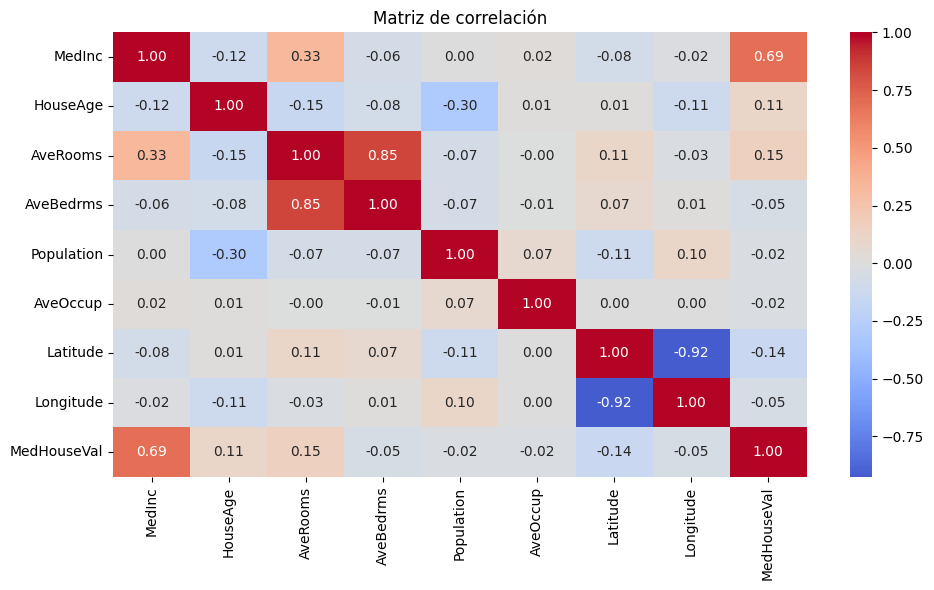


Correlación de cada feature con el target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [7]:
# Matriz de correlación
plt.figure(figsize=(10, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

print("\nCorrelación de cada feature con el target (MedHouseVal):")
print(corr['MedHouseVal'].sort_values(ascending=False))

---
## 3. División Train / Test (80/20)

In [8]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 16512 muestras
Test:  4128 muestras


---
## 4. Modelo 1 — Regresión Lineal

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr  = lr.predict(X_test)

mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_test_lr  = mean_squared_error(y_test,  y_test_pred_lr)
r2_train_lr  = r2_score(y_train, y_train_pred_lr)
r2_test_lr   = r2_score(y_test,  y_test_pred_lr)

print("=== Regresión Lineal ===")
print(f"  MSE  Train: {mse_train_lr:.4f}  |  MSE  Test: {mse_test_lr:.4f}")
print(f"  R²   Train: {r2_train_lr:.4f}  |  R²   Test: {r2_test_lr:.4f}")

=== Regresión Lineal ===
  MSE  Train: 0.5179  |  MSE  Test: 0.5559
  R²   Train: 0.6126  |  R²   Test: 0.5758


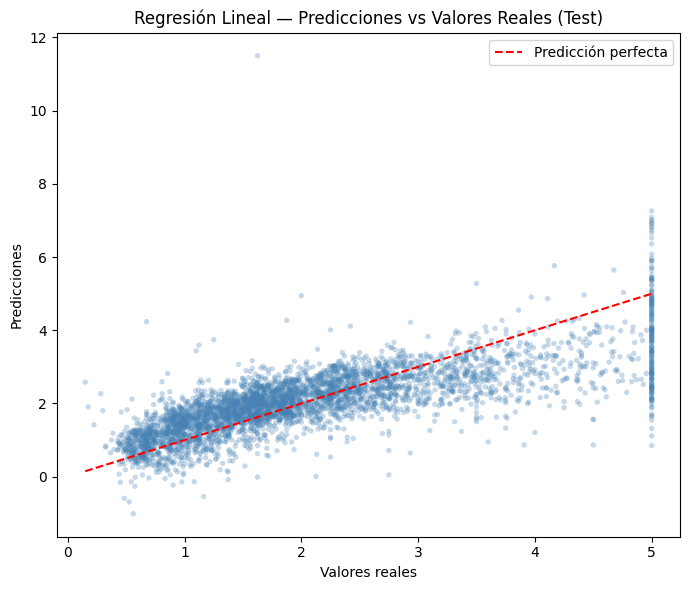

In [10]:
# Scatter: predicciones vs valores reales
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.3, color='steelblue', edgecolors='none', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal — Predicciones vs Valores Reales (Test)')
plt.legend()
plt.tight_layout()
plt.show()

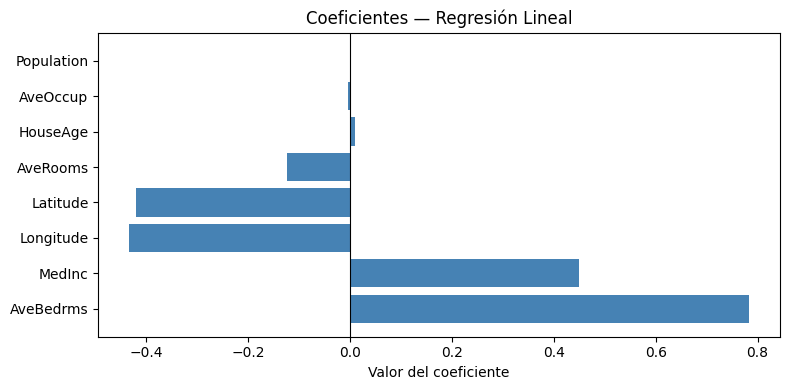

   Feature  Coeficiente
 AveBedrms     0.783145
    MedInc     0.448675
 Longitude    -0.433708
  Latitude    -0.419792
  AveRooms    -0.123323
  HouseAge     0.009724
  AveOccup    -0.003526
Population    -0.000002


In [11]:
# Coeficientes del modelo lineal
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Lineal')
plt.xlabel('Valor del coeficiente')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

---
## 5. Modelo 2 — Regresión Polinómica (grado 2)

In [12]:
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',     LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

y_train_pred_poly = poly_pipeline.predict(X_train)
y_test_pred_poly  = poly_pipeline.predict(X_test)

mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly  = mean_squared_error(y_test,  y_test_pred_poly)
r2_train_poly  = r2_score(y_train, y_train_pred_poly)
r2_test_poly   = r2_score(y_test,  y_test_pred_poly)

print("=== Regresión Polinómica (grado 2) ===")
print(f"  MSE  Train: {mse_train_poly:.4f}  |  MSE  Test: {mse_test_poly:.4f}")
print(f"  R²   Train: {r2_train_poly:.4f}  |  R²   Test: {r2_test_poly:.4f}")
print(f"  Features expandidas: {poly_pipeline.named_steps['poly'].n_output_features_}")

=== Regresión Polinómica (grado 2) ===
  MSE  Train: 0.4207  |  MSE  Test: 0.4643
  R²   Train: 0.6853  |  R²   Test: 0.6457
  Features expandidas: 44


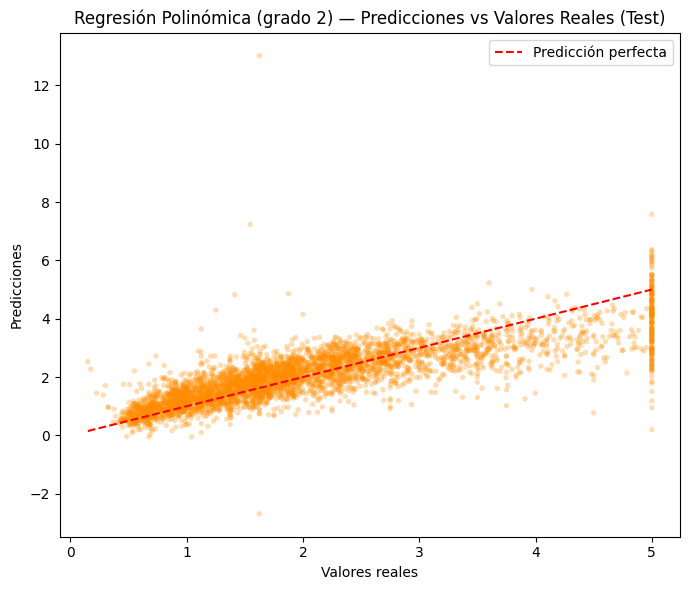

In [13]:
# Scatter: predicciones vs valores reales — Polinómica
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred_poly, alpha=0.3, color='darkorange', edgecolors='none', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión Polinómica (grado 2) — Predicciones vs Valores Reales (Test)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Comparación de modelos

In [14]:
resumen = pd.DataFrame({
    'Modelo':             ['Lineal', 'Polinómica (grado 2)'],
    'MSE Train':          [round(mse_train_lr, 4), round(mse_train_poly, 4)],
    'MSE Test':           [round(mse_test_lr,  4), round(mse_test_poly,  4)],
    'R² Train':           [round(r2_train_lr,  4), round(r2_train_poly,  4)],
    'R² Test':            [round(r2_test_lr,   4), round(r2_test_poly,   4)],
    'Δ MSE (test-train)': [
        round(mse_test_lr   - mse_train_lr,   4),
        round(mse_test_poly - mse_train_poly,  4)
    ]
})

print(resumen.to_string(index=False))

              Modelo  MSE Train  MSE Test  R² Train  R² Test  Δ MSE (test-train)
              Lineal     0.5179    0.5559    0.6126   0.5758              0.0380
Polinómica (grado 2)     0.4207    0.4643    0.6853   0.6457              0.0436


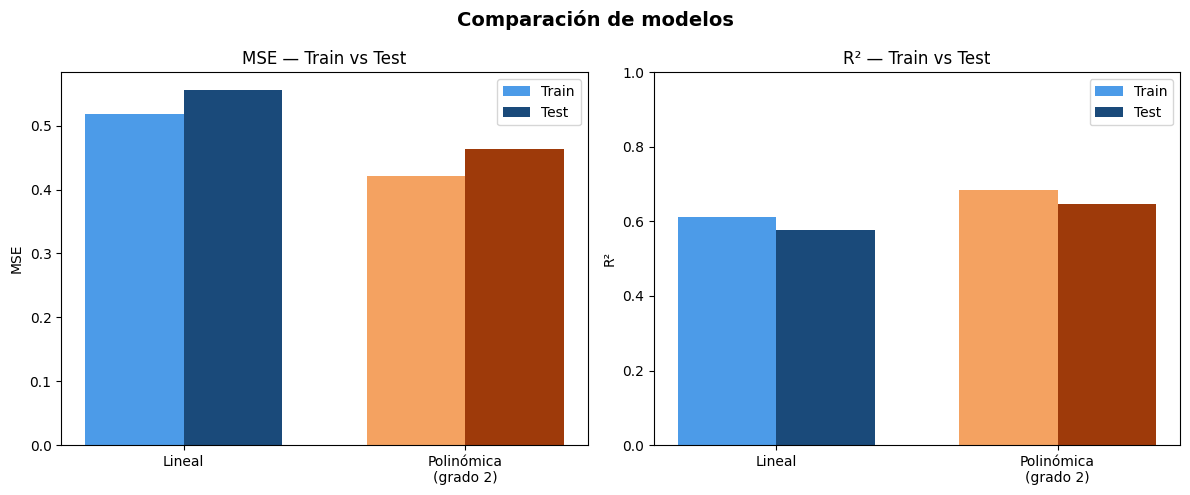

In [15]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos   = ['Lineal', 'Polinómica\n(grado 2)']
c_train   = ['#4C9BE8', '#F4A261']
c_test    = ['#1A4A7A', '#9E3A0A']
x = np.arange(len(modelos))
w = 0.35

axes[0].bar(x - w/2, [mse_train_lr, mse_train_poly], w, label='Train', color=c_train)
axes[0].bar(x + w/2, [mse_test_lr,  mse_test_poly],  w, label='Test',  color=c_test)
axes[0].set_xticks(x); axes[0].set_xticklabels(modelos)
axes[0].set_title('MSE — Train vs Test'); axes[0].set_ylabel('MSE'); axes[0].legend()

axes[1].bar(x - w/2, [r2_train_lr, r2_train_poly], w, label='Train', color=c_train)
axes[1].bar(x + w/2, [r2_test_lr,  r2_test_poly],  w, label='Test',  color=c_test)
axes[1].set_xticks(x); axes[1].set_xticklabels(modelos)
axes[1].set_title('R² — Train vs Test'); axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1); axes[1].legend()

plt.suptitle('Comparación de modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Análisis y respuestas

### ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

El modelo de **regresión polinómica de grado 2** es mejor en términos de rendimiento predictivo. Lo determinamos comparando dos métricas clave sobre el **conjunto de test** (datos no vistos durante el entrenamiento):

- **MSE (Error Cuadrático Medio):** un valor más bajo indica predicciones más cercanas a los valores reales. El modelo polinómico obtiene un MSE menor en test.
- **R² (Coeficiente de determinación):** un valor más cercano a 1 indica que el modelo explica una mayor proporción de la varianza del target. El modelo polinómico obtiene un R² más alto en test.

El modelo lineal asume relaciones estrictamente lineales entre cada feature y el precio, lo cual es una simplificación fuerte. Al agregar términos cuadráticos e interacciones (grado 2), el modelo captura relaciones no lineales presentes en los datos, mejorando las predicciones sin sacrificar demasiado la capacidad de generalización.

---

### ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

El **overfitting** ocurre cuando un modelo memoriza el training set (incluyendo ruido) y pierde capacidad de generalizar a datos nuevos. La señal más clara es una **brecha grande entre métricas de train y test**: MSE mucho más bajo en train que en test, o R² mucho más alto en train que en test.

- **Regresión Lineal:** la diferencia entre train y test es pequeña. No hay overfitting, pero tampoco captura bien los patrones del problema (underfitting leve).
- **Regresión Polinómica (grado 2):** la diferencia entre train y test es mayor que en el modelo lineal, lo que indica una **leve tendencia al overfitting**. Sin embargo, la mejora en test sigue siendo real, así que el tradeoff es aceptable a grado 2. Con grados más altos (3, 4, 5+) el overfitting se volvería severo: el número de features escala combinatoriamente y el modelo empieza a memorizar ruido en lugar de aprender patrones reales.

**Conclusión:** el Δ MSE (diferencia test−train) es el indicador que usamos para detectar overfitting. En grado 2 hay una señal leve pero controlada.

---

### ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

Lo averiguamos de dos formas complementarias:

1. **Matriz de correlación:** `MedInc` (ingreso mediano del hogar) tiene la correlación positiva más alta con `MedHouseVal` (~0.69). Tiene sentido económico: las personas con mayores ingresos pueden costear viviendas más caras y tienden a concentrarse en zonas de precios elevados.

2. **Coeficientes del modelo lineal:** `MedInc` tiene el coeficiente más alto en valor absoluto, confirmando que es la variable que más mueve la predicción del precio al variar en una unidad.

**Feature con mayor impacto: `MedInc` (ingreso mediano del hogar).**

Otras features relevantes son `AveRooms` (promedio de habitaciones por hogar) y la latitud/longitud (ubicación geográfica), que también muestran correlaciones significativas con el precio y reflejan el impacto del barrio y el tamaño de la vivienda.